In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

drop_cols = [
    "difficulty", "label",
    "srv_serror_rate", "dst_host_srv_serror_rate",
    "srv_rerror_rate", "dst_host_srv_rerror_rate",
]
categorical_cols = ["protocol_type", "service", "flag"]

In [5]:
train_df = pd.read_csv("../data/KDDTrain.txt", names=columns)
test_df = pd.read_csv("../data/KDDTest.txt", names=columns)

train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

X_train = train_df.drop(columns=["binary_label"])
y_train = train_df["binary_label"]
X_test = test_df.drop(columns=["binary_label"])
y_test = test_df["binary_label"]

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("Confusion matrix:\n", cm)

    return {"name": name, "model": model, "acc": acc, "prec": prec,
            "rec": rec, "f1": f1, "cm": cm}

results = []

In [7]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
results.append(evaluate("Random Forest", rf, X_train, y_train, X_test, y_test))


=== Random Forest ===
Accuracy:  0.7742
Precision: 0.9680
Recall:    0.6239
F1 Score:  0.7588
Confusion matrix:
 [[9446  265]
 [4826 8007]]


In [8]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)
results.append(evaluate("XGBoost", xgb, X_train, y_train, X_test, y_test))


=== XGBoost ===
Accuracy:  0.8079
Precision: 0.9689
Recall:    0.6846
F1 Score:  0.8023
Confusion matrix:
 [[9429  282]
 [4048 8785]]


In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate("Logistic Regression", lr, X_train_scaled, y_train, X_test_scaled, y_test))


=== Logistic Regression ===
Accuracy:  0.7518
Precision: 0.9245
Recall:    0.6142
F1 Score:  0.7380
Confusion matrix:
 [[9067  644]
 [4951 7882]]




=== COMPARISON TABLE ===
              Model  Accuracy  Precision   Recall       F1
      Random Forest  0.774175   0.967964 0.623938 0.758778
            XGBoost  0.807931   0.968898 0.684563 0.802283
Logistic Regression  0.751819   0.924466 0.614198 0.738050


(0.0, 1.05)

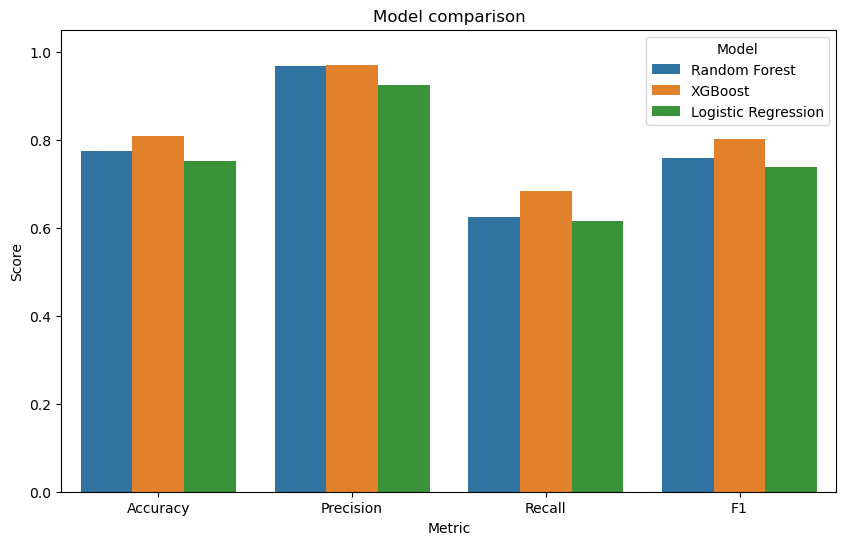

In [10]:
comparison = pd.DataFrame([{"Model": r["name"], "Accuracy": r["acc"], "Precision": r["prec"], "Recall": r["rec"], "F1": r["f1"]} for r in results])
print("\n\n=== COMPARISON TABLE ===")
print(comparison.to_string(index=False))

comparison_melted = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10,6))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model")
plt.title("Model comparison")
plt.ylim(0, 1.05)